# Aral Sea Model Simulations
This notebook assembles Aral Sea discharge experiments, builds the river forcing inputs, runs the connected model, and compares the simulated time series with observations before saving the outputs for later analysis.

## Set Up Imports and Project Paths
The notebook adds the project root to `sys.path`, imports the analysis libraries, loads `config_aral.yaml`, and creates the figure and results directories used throughout the rest of the workflow.

In [14]:
# setup imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import yaml

import importlib
import src.aral as aral


#from src.paths import GRDC
from ewatercycle.observation.grdc import get_grdc_data

# load the project configuration
config_path = PROJECT_ROOT / "config_aral.yaml"
with config_path.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

def resolve_project_path(config_path_value):
    return PROJECT_ROOT / config_path_value


figures_dir = resolve_project_path(config["paths"]["figures_dir"])
figures_dir.mkdir(parents=True, exist_ok=True)
aral_sea_results_dir = resolve_project_path(config["paths"]["aral_sea_results_dir"])
aral_sea_results_dir.mkdir(parents=True, exist_ok=True)

config_path, config["project"]["title"]

(PosixPath('/home/avandervee3/aral_sea_full_project/config_aral.yaml'),
 'Aral Sea Level Modelling')

## Load Discharge Datasets
The historical and future station NetCDF files are opened here, and the `discharge` variables are extracted as DataArrays so the simulation code can use them as river forcing inputs.

In [16]:
historical_nc = resolve_project_path(config["aral_sea_experiment"]["final_station_historical"])
future_nc = resolve_project_path(config["aral_sea_experiment"]["final_station_future"])

historical_ds = xr.load_dataset(historical_nc)
future_ds = xr.load_dataset(future_nc)

historical_da = historical_ds["discharge"]
future_da = future_ds["discharge"]

ARAL_FORCING_FOLDER = resolve_project_path(config["paths"]["forcing_dir"]) / "aral_sea" / "ERA5" / "AralSea" / "1940-2015" / "work" / "diagnostic" / "script" 



PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/aral_sea/ERA5/AralSea/1940-2015/work/diagnostic/script')

In [4]:
historical_da.coords['experiment'].values

array(['run_id=r001__model=era5__scenario=era5__type=raw__parameter_set=uncalibrated__era=historical',
       'run_id=r002__model=era5__scenario=era5__type=raw__parameter_set=overall_calibrated__era=historical',
       'run_id=r003__model=era5__scenario=era5__type=raw__parameter_set=amu_calibrated__era=historical',
       'run_id=r004__model=era5__scenario=era5__type=raw__parameter_set=syr_calibrated__era=historical',
       'run_id=r005__model=MIROC6__scenario=historical__type=regridded__parameter_set=overall_calibrated__era=historical',
       'run_id=r006__model=MPI-ESM1-2-HR__scenario=historical__type=regridded__parameter_set=overall_calibrated__era=historical',
       'run_id=r007__model=CanESM5__scenario=historical__type=regridded__parameter_set=overall_calibrated__era=historical',
       'run_id=r008__model=MIROC6__scenario=historical__type=bias_corrected__parameter_set=overall_calibrated__era=historical',
       'run_id=r009__model=MPI-ESM1-2-HR__scenario=historical__type=bias_

## Define Experiment Labels
The experiment strings are parsed into key-value metadata, and the raw labels are converted into readable names so the plots and saved outputs are easier to interpret.

In [5]:
def parse_experiment(exp_name):
    return dict(part.split("=") for part in exp_name.split("__"))

TYPE_LABELS = {
    "raw": "raw",
    "regridded": "uncorrected",
    "bias_corrected": "bias corrected",
}

def experiment_label(exp_name):
    p = parse_experiment(exp_name)
    model = p["model"]
    type_ = TYPE_LABELS.get(p["type"], p["type"])
    param = p["parameter_set"]
    
    if model == "era5":
        return f"ERA5 - {param}"
    else:
        return f"{model} - {type_}"

## Build River Inputs
River objects are created for each experiment using the Amu Darya and Syr Darya discharge series, and an additional ERA5 configuration combines the calibrated sources needed for the mixed setup.

In [6]:
rivers = {}
for exp_name in historical_da.experiment.values:
    rivers[exp_name] = {
        "Amu": aral.River(
            historical_da.sel(experiment=exp_name, station="Chatly"),
            name=f"Amu - {experiment_label(exp_name)}"
        ),
        "Syr": aral.River(
            historical_da.sel(experiment=exp_name, station="Kazalinsk"),
            name=f"Syr - {experiment_label(exp_name)}"
        )
    }

era5_overall = 'run_id=r002__model=era5__scenario=era5__type=raw__parameter_set=overall_calibrated__era=historical'
era5_amu_cal = 'run_id=r003__model=era5__scenario=era5__type=raw__parameter_set=amu_calibrated__era=historical'



rivers["era5_river_specific_combined"] = {
    "Amu": rivers[era5_amu_cal]["Amu"],
    "Syr": rivers[era5_overall]["Syr"]
}

In [19]:
aral_precip = xr.open_dataset(ARAL_FORCING_FOLDER / "OBS6_ERA5_reanaly_1_day_pr_1940-2015.nc")
aral_evap = xr.open_dataset(ARAL_FORCING_FOLDER / "Derived_Makkink_evspsblpot.nc")
ahv_file = resolve_project_path(config["aral_sea_experiment"]["bathymetry_path"])
initial_volume = 1100

## Define and Run Simulations
A small wrapper calls `run_connected_aral_model` with the shared meteorological forcing, the selected river pair, the bathymetry file, and the initial lake volume, then runs every available river configuration.

In [20]:
def run_sim(sim_name, rivers_dict):
    return aral.run_connected_aral_model(
        aral_meteo = aral_evap,
        aral_precip = aral_precip,
        rivers=[rivers_dict["Amu"], rivers_dict["Syr"]],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2014-12-31",
        tqdm_position=1,
    )


importlib.reload(aral)
results = {}
labels = []
for sim, rivers_dict in rivers.items():
    results[sim] = run_sim(sim, rivers_dict)
    if sim == "era5_river_specific_combined":
        labels.append("ERA5 - river specific combined")
    else:
        labels.append(experiment_label(sim))

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Plot All Simulation Results
The observation series is generated and the full set of model outputs is plotted together so the behavior of each experiment can be compared in a single figure.

Found 1 NetCDF files in /home/avandervee3/aral_sea_full_project/data/dahiti


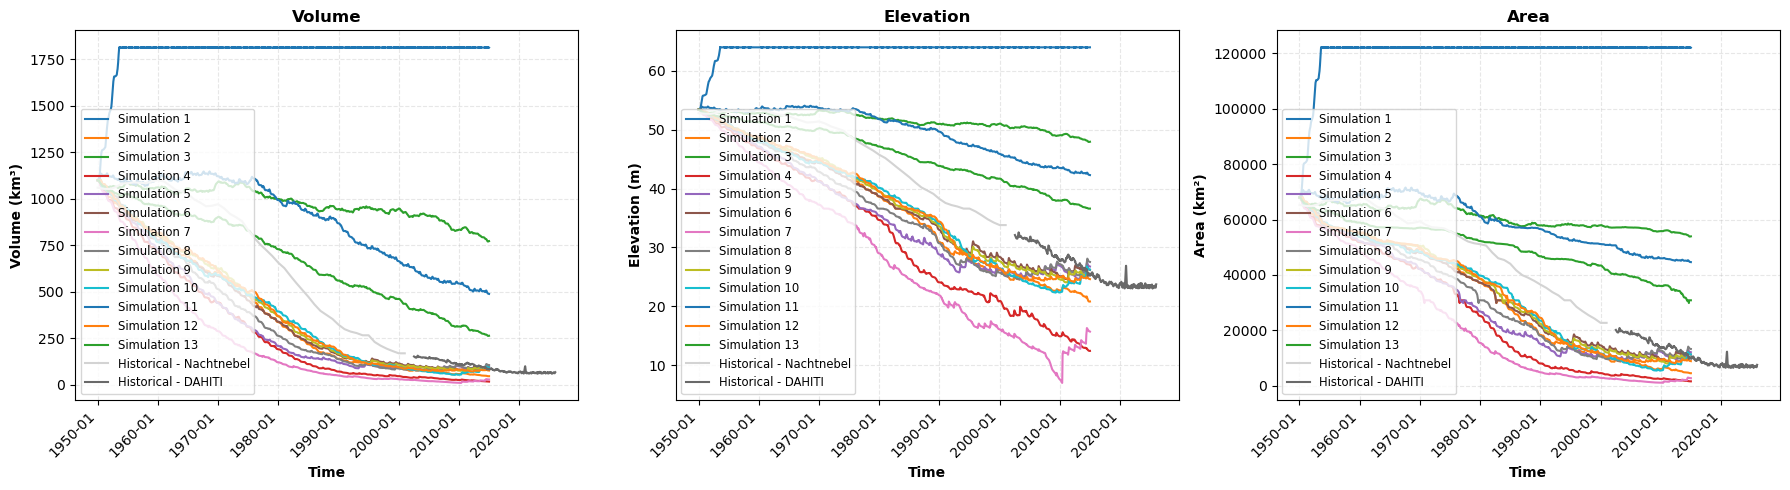

In [9]:

observation = aral.make_obs()
aral.plot_aral_results(
    list(results.values()),
    observations=observation,    
)

## Plot Elevation Comparison
As an example a subset of simulations is selected and compared against observations to highlight the elevation response for the, in this case, bias-corrected scenarios, and the figure is written to the figures directory.

Plot successfully saved to: /home/avandervee3/aral_sea_full_project/results/figures/aral_sea_elevation_bias_corrected.pdf


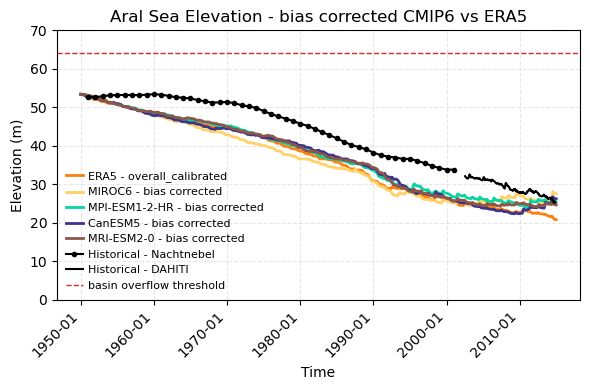

In [12]:
indices = [1,7, 8, 9, 11]
all_keys = list(results.keys())

selected_keys = [all_keys[i] for i in indices]
selected_labels = [labels[i] for i in indices]
importlib.reload(aral)
aral.plot_aral_elevation(
    [results[k] for k in selected_keys],
    labels=selected_labels,
    observations=observation,
    title = "Aral Sea Elevation - bias corrected CMIP6 vs ERA5",
    save_path = figures_dir / "aral_sea_elevation_bias_corrected.pdf"
)

## Save and Reload Results
The simulation data frames are combined into a NetCDF dataset, saved to the simulations directory, and loaded back.

In [15]:
output_dir = aral_sea_results_dir / "simulations" 
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / "historical_results.nc"

# Save
sim_names = [str(k) for k in results.keys()]
ds = xr.concat(
    [xr.Dataset.from_dataframe(df.set_index("time")) for df in results.values()],
    dim=pd.Index(sim_names, name="simulation")
)
ds.to_netcdf(output_file)

# Load
ds = xr.open_dataset(output_file)
sim_names = ds.simulation.values.tolist()
results = {}
labels = []
for sim_name in sim_names:
    df = ds.sel(simulation=sim_name).to_dataframe().reset_index()
    df["time"] = pd.to_datetime(df["time"])
    results[sim_name] = df
    if sim_name == "era5_river_specific_combined":
        labels.append("ERA5 - river specific combined")
    else:
        labels.append(experiment_label(sim_name))